# Corrective RAG (Corrective Retrieval-Augmented Generation)

## Table of Contents
1. [What is Corrective RAG?](#what-is-corrective-rag)
2. [Why, When, and How to Use It](#why-when-and-how-to-use-it)
3. [Flowchart & State Machine](#flowchart--state-machine)
4. [Pros and Cons](#pros-and-cons)
5. [Real-World Case Study: Out-of-Distribution Product FAQ Support](#real-world-case-study-out-of-distribution-product-faq-support)
6. [Building from Scratch in LangGraph](#building-from-scratch-in-langgraph)

---

## What is Corrective RAG?

**Corrective RAG (CRAG)** is a RAG design pattern introduced to handle inaccurate or irrelevant document retrieval. Instead of blindly passing retrieved documents to the generator, CRAG inserts a **Document Evaluator** (a grading step) between retrieval and generation. 

Based on the evaluation of the retrieved documents, the system takes corrective actions:
- **Correct (Relevant)**: If the documents are highly relevant, the system directly proceeds to generation.
- **Incorrect (Irrelevant)**: If the documents are completely irrelevant, the system discards them, reformulates the user query, and retrieves from an external source (like a Web Search API).
- **Ambiguous (Partially Relevant)**: If the documents are partially relevant, the system combines the local documents with external web search results to ensure complete coverage before generating.

---

## Why, When, and How to Use It

### Why Use Corrective RAG?
Standard RAG systems fail when the local vector database contains stale, incomplete, or irrelevant information. The LLM is forced to generate an answer using bad context, which inevitably causes hallucinations or unhelpful "I don't know" responses. CRAG solves this by actively grading documents and leveraging backup search tools to "correct" the context.

### When to Use It
- **Rapidly Evolving Knowledge Bases**: Where internal company documentation might lag behind actual system status or news.
- **Out-of-Distribution Queries**: When users ask questions that are tangential to the core document index, requiring an external search fallback.
- **Accuracy-Critical Support Desk**: Where providing outdated product information directly harms user trust.

### How it Works
1. **Retrieve**: Pull document candidates from the local vector database.
2. **Evaluate/Grade**: Evaluate the quality and relevance of each document against the query.
3. **Branching Decision**:
   - Relevant -> Send straight to the generator.
   - Irrelevant / Ambiguous -> Route to Query Rewriter -> Trigger External Web Search.
4. **Context Merging**: Combine valid local files with web search results.
5. **Generate**: Synthesize the final, verified answer.

---

## Flowchart & State Machine

### High-Level CRAG Flowchart

```mermaid
graph TD
    UserQuery[User Query] --> LocalRetrieve[Retrieve Local Vector DB]
    LocalRetrieve --> DocGrader{Document Evaluator}
    
    DocGrader -->|All Relevant| Generate[Generate Answer]
    DocGrader -->|Ambiguous / Partial| Merge[Merge Local Context + Web Search]
    DocGrader -->|All Irrelevant| Rewrite[Query Rewriter]
    
    Rewrite --> WebSearch[Web Search API]
    WebSearch --> Generate
    
    Merge --> Generate
    Generate --> Output[Final Corrected Response]
```

### Detailed LangGraph State Machine

```mermaid
stateDiagram-v2
    [*] --> RetrieveLocal: Start
    RetrieveLocal --> GradeDocuments
    
    GradeDocuments --> GenerateResponse: Grade = Correct (All Relevant)
    GradeDocuments --> WebSearch: Grade = Ambiguous (Merge Search)
    GradeDocuments --> TransformQuery: Grade = Incorrect (All Irrelevant)
    
    TransformQuery --> WebSearch
    WebSearch --> GenerateResponse
    GenerateResponse --> [*]
```

---

## Pros and Cons

### Pros
- **Hallucination Reducer**: Prevents the generator from utilizing misleading or out-of-context documents.
- **Automated Fallback**: Seamlessly bridges the gap between private internal documents and the public web.
- **Self-Correction**: Dynamically alters the query to improve web search relevance when local index match fails.

### Cons
- **Higher Latency**: The grading step and external search api call add time to the processing pipeline.
- **External Dependency Risk**: Relying on web search engines introduces rates, keys, and uptime dependencies.
- **Token Inflation**: Re-running queries and passing multiple sets of documents consumes more LLM tokens.

---

## Real-World Case Study: Out-of-Distribution Product FAQ Support

### Scenario
An electronics manufacturer, **ElectroNova**, sells smart IoT plugs. 
- The local vector DB contains specifications for their existing plugs (SmartPlug v1, SmartPlug v2).
- A customer submits a query about a newly announced prototype, **SmartPlug Pro**, which hasn't been added to the internal manuals database yet.
- Without CRAG, the retriever returns manuals for SmartPlug v2. The generator incorrectly answers using v2 stats, leading to false information.
- With CRAG, the document grader flags the v2 manuals as irrelevant to "SmartPlug Pro". The system rewrites the query to "ElectroNova SmartPlug Pro specifications", searches the web, retrieves the recent press release, and gives the correct answer.

---

## Building from Scratch in LangGraph

The LangGraph implementation features a document grading node using structured JSON output, a query-transformation node, a web search execution node, and conditional routing based on grading results. Explore the complete python file to see how these elements combine in code.

## Complete Implementation Code

In [1]:
"""
Corrective RAG (Corrective Retrieval-Augmented Generation) - LangGraph Implementation
=====================================================================================

This script implements a Corrective RAG (CRAG) pattern:
1. Local Retriever: Searches a local database.
2. Document Evaluator / Grader: Evaluates document relevance to check if local data is incorrect/stale.
3. Query Transformer: Rewrites queries when local documents fail grading.
4. Web Search Fallback: Searches external databases to retrieve correct/current data.
5. Generator: Compiles the finalized corrected response.
"""



'\nCorrective RAG (Corrective Retrieval-Augmented Generation) - LangGraph Implementation\n=====================================================================================\n\nThis script implements a Corrective RAG (CRAG) pattern:\n1. Local Retriever: Searches a local database.\n2. Document Evaluator / Grader: Evaluates document relevance to check if local data is incorrect/stale.\n3. Query Transformer: Rewrites queries when local documents fail grading.\n4. Web Search Fallback: Searches external databases to retrieve correct/current data.\n5. Generator: Compiles the finalized corrected response.\n'

In [3]:

import os
from typing import Literal, List, Dict, Any
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState

# Load environment variables
# load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '..', '.env'))
load_dotenv()

# ==============================================================================
# Dynamic Dual-Provider LLM Setup (OpenAI / Groq)
# ==============================================================================

if os.environ.get("OPENAI_API_KEY"):
    print("[INFO] Detected OpenAI API Key. Running with OpenAI...")
    from langchain_openai import ChatOpenAI
    eval_model = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    transform_model = ChatOpenAI(model='gpt-4o-mini', temperature=0)
    gen_model = ChatOpenAI(model='gpt-4o', temperature=0.1)
elif os.environ.get("GROQ_API_KEY"):
    print("[INFO] Detected Groq API Key. Running with Groq...")
    from langchain_groq import ChatGroq
    # Llama 3.3 70B is excellent for grading and routing logic
    eval_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    transform_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    gen_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0.1)
else:
    raise ValueError("Missing credentials. Set OPENAI_API_KEY or GROQ_API_KEY in your .env file.")



[INFO] Detected Groq API Key. Running with Groq...


In [4]:

# ==============================================================================
# Step 1: Define Mock Database (Local Vector DB & Web status DB)
# ==============================================================================

# Local product manual index
LOCAL_FAQ_DB = [
    {
        "product": "SmartPlug v1",
        "doc": "ElectroNova SmartPlug v1 Product Details: Supports loads up to 1000W. Price: $14.99. Standard on/off timing schedule via ElectroNova Basic App. Connectivity: 2.4GHz Wi-Fi only."
    },
    {
        "product": "SmartPlug v2",
        "doc": "ElectroNova SmartPlug v2 Product Details: Supports loads up to 1500W. Price: $19.99. Advanced scheduling, countdown timers, and voice assistant integration (Alexa/Google Home). Connectivity: Dual-band Wi-Fi."
    }
]

# External Web Search index (recent news/launches)
WEB_SEARCH_DB = [
    {
        "query_keywords": ["smartplug pro", "smartplug", "features", "specs"],
        "source": "TechCrunch Product Launch Article (Yesterday)",
        "content": (
            "ElectroNova launches 'SmartPlug Pro' for heavy-duty appliances. "
            "Features energy-monitoring dashboards, overload protection up to 1800W, "
            "and offline local network control. Priced at $29.99, it is available immediately."
        )
    }
]



In [5]:

# ==============================================================================
# Step 2: Define Retrieval Helper Functions
# ==============================================================================

def retrieve_local_faq(query: str) -> List[str]:
    """Retrieves documents matching keywords in the local DB."""
    query_lower = query.lower()
    results = []
    for doc in LOCAL_FAQ_DB:
        if any(word in doc["doc"].lower() for word in query_lower.split() if len(word) > 3):
            results.append(doc["doc"])
    return results

def execute_external_web_search(query: str) -> List[str]:
    """Simulates querying external search index for out-of-distribution queries."""
    query_lower = query.lower()
    results = []
    print(f"   [Web Search] Executing live search for query: '{query}'...")
    for doc in WEB_SEARCH_DB:
        combined_keywords = " ".join(doc["query_keywords"]) + " " + doc["content"]
        if any(word in combined_keywords.lower() for word in query_lower.split() if len(word) > 3):
            results.append(f"[{doc['source']}]: {doc['content']}")
    return results


In [6]:


# ==============================================================================
# Step 3: Define Structured Grading Schema
# ==============================================================================

class DocGrade(BaseModel):
    """Evaluation result for a single document's relevance to the user query."""
    relevance: Literal["yes", "no"] = Field(
        description="Choose 'yes' if the document is highly relevant to the query and contains information that helps answer it. Choose 'no' if the document is about a different product version, outdated, or completely off-topic."
    )
    reasoning: str = Field(description="Explanation of the grading decision.")

structured_grader = eval_model.with_structured_output(DocGrade)


In [7]:


# ==============================================================================
# Step 4: Define Graph State
# ==============================================================================

class CRAGState(MessagesState):
    """State containing retrieved documents, grading status, and query updates."""
    retrieved_docs: List[str]  # Active context list
    needs_web_search: bool     # Flag triggering corrective web search
    transformed_query: str     # Optimized query for web search
    generation: str            # Final compiled response



In [8]:

# ==============================================================================
# Step 5: Implement Graph Nodes
# ==============================================================================

def retrieve_local_node(state: CRAGState) -> dict:
    """Queries local vector database for matching records."""
    user_query = state["messages"][-1].content
    print(f"\n[1. Retriever] Searching local Vector DB for: '{user_query}'")
    
    docs = retrieve_local_faq(user_query)
    print(f"   Retrieved {len(docs)} document candidate(s).")
    
    return {"retrieved_docs": docs, "needs_web_search": False}


def evaluate_documents_node(state: CRAGState) -> dict:
    """Grades retrieved documents. Sets search flag if documents are irrelevant."""
    user_query = state["messages"][-1].content
    docs = state.get("retrieved_docs", [])
    
    print("\n[2. Evaluator] Grading document relevance...")
    
    if not docs:
        print("   No documents retrieved. Marking search fallback immediately.")
        return {"needs_web_search": True}
        
    valid_docs = []
    needs_search = False
    
    for doc in docs:
        prompt = (
            "Evaluate whether this document contains relevant details to answer the query. "
            "If the query asks about a specific product/version (e.g. SmartPlug Pro) and the "
            "document only discusses a different version (e.g. SmartPlug v1 or v2), mark relevance='no'.\n\n"
            f"User Query: {user_query}\n"
            f"Document:\n{doc}"
        )
        grade = structured_grader.invoke([HumanMessage(content=prompt)])
        
        if grade.relevance == "yes":
            print(f"   [Doc Relevant: YES] Details: {grade.reasoning}")
            valid_docs.append(doc)
        else:
            print(f"   [Doc Relevant: NO] Details: {grade.reasoning}")
            needs_search = True  # Trigger search fallback if any doc fails
            
    # If all docs were scored irrelevant, clear list to prevent polluted generation
    return {
        "retrieved_docs": valid_docs,
        "needs_web_search": needs_search or (len(valid_docs) == 0)
    }


def transform_query_node(state: CRAGState) -> dict:
    """Reformulates query to expand web search accuracy."""
    user_query = state["messages"][-1].content
    print(f"\n[3. Query Transformer] Optimizing query for external web search...")
    
    prompt = (
        "You are a search query optimizer. The user's query failed to find relevant results "
        "in our internal documentation. Rewrite the query to optimize it for a public search engine. "
        "Focus on search-friendly keywords, product brands, and specific features.\n\n"
        f"Original Query: {user_query}"
    )
    
    rewritten = transform_model.invoke([HumanMessage(content=prompt)])
    print(f"   Optimized Query: '{rewritten.content}'")
    
    return {"transformed_query": rewritten.content}


def execute_web_search_node(state: CRAGState) -> dict:
    """Retrieves corrective/supplementary context from the web search API."""
    query = state.get("transformed_query") or state["messages"][-1].content
    docs = state.get("retrieved_docs", [])
    
    print(f"\n[4. Web Search] Invoking fallback search API...")
    web_results = execute_external_web_search(query)
    
    print(f"   Found {len(web_results)} relevant web result(s).")
    
    # Merge local valid context with the new web context
    merged_docs = docs + web_results
    return {"retrieved_docs": merged_docs}


def generate_response_node(state: CRAGState) -> dict:
    """Compiles the final, factual response based on corrected context."""
    user_query = state["messages"][-1].content
    context = "\n\n".join(state.get("retrieved_docs", []))
    
    print("\n[5. Generator] Constructing finalized response...")
    
    prompt = (
        "You are ElectroNova Technical Support. Answer the user query using only the "
        "provided context. If the answer cannot be determined from the context, "
        "state that clearly. Do not make assumptions.\n\n"
        f"Context:\n{context if context else 'No document context available.'}\n\n"
        f"User Query: {user_query}"
    )
    
    response = gen_model.invoke([HumanMessage(content=prompt)])
    
    return {
        "generation": response.content,
        "messages": [AIMessage(content=response.content, name="TechnicalSupport")]
    }


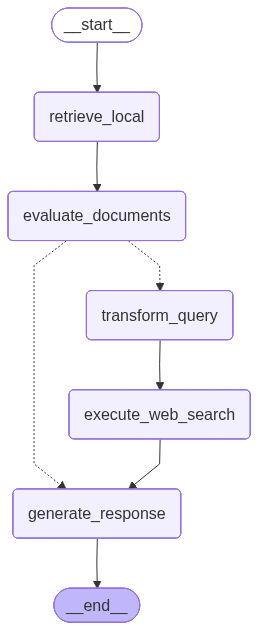

In [9]:


# ==============================================================================
# Step 6: Define Conditional Routers (State Machine Logic)
# ==============================================================================

def route_evaluator_decision(state: CRAGState) -> str:
    """Routes based on the document evaluation relevance flags."""
    if state["needs_web_search"]:
        return "transform_query"
    return "generate_response"


# Assemble the graph
workflow = StateGraph(CRAGState)

# Add Nodes
workflow.add_node("retrieve_local", retrieve_local_node)
workflow.add_node("evaluate_documents", evaluate_documents_node)
workflow.add_node("transform_query", transform_query_node)
workflow.add_node("execute_web_search", execute_web_search_node)
workflow.add_node("generate_response", generate_response_node)

# Wire Edges
workflow.add_edge(START, "retrieve_local")
workflow.add_edge("retrieve_local", "evaluate_documents")

workflow.add_conditional_edges(
    "evaluate_documents",
    route_evaluator_decision,
    {
        "transform_query": "transform_query",
        "generate_response": "generate_response"
    }
)

workflow.add_edge("transform_query", "execute_web_search")
workflow.add_edge("execute_web_search", "generate_response")
workflow.add_edge("generate_response", END)

# Compile
compiled_crag = workflow.compile()
compiled_crag


In [10]:

# ==============================================================================
# Step 7: Execution and Demonstration
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("CORRECTIVE RAG (CRAG) SUPPORT ENGINE - Start")
    print("=" * 80)
    
    # Test Cases:
    # 1. Matches local vector DB (Direct Gen)
    # 2. Out-of-Distribution product (Triggers CRAG search correction)
    
    queries = [
        "What features does the SmartPlug v2 have and how much does it cost?",
        "Tell me about the new SmartPlug Pro features and its pricing details."
    ]
    
    for idx, query in enumerate(queries, 1):
        print(f"\n\n[TEST CASE #{idx}] Query: \"{query}\"")
        print("-" * 80)
        
        inputs = {
            "messages": [HumanMessage(content=query)],
            "retrieved_docs": [],
            "needs_web_search": False,
            "transformed_query": "",
            "generation": ""
        }
        
        result = compiled_crag.invoke(inputs, {"recursion_limit": 20})
        
        print("\n[RESULT]")
        print(f"Final Output:\n{result['generation']}")
        print("=" * 80)


CORRECTIVE RAG (CRAG) SUPPORT ENGINE - Start


[TEST CASE #1] Query: "What features does the SmartPlug v2 have and how much does it cost?"
--------------------------------------------------------------------------------

[1. Retriever] Searching local Vector DB for: 'What features does the SmartPlug v2 have and how much does it cost?'
   Retrieved 2 document candidate(s).

[2. Evaluator] Grading document relevance...
   [Doc Relevant: NO] Details: The document discusses SmartPlug v1, but the query asks about SmartPlug v2, making it irrelevant to the user's query.
   [Doc Relevant: YES] Details: The document is about the SmartPlug v2, which matches the product version in the user query, and it provides information about the product's features and price.

[3. Query Transformer] Optimizing query for external web search...
   Optimized Query: 'To optimize the query for a public search engine, I would rewrite it as:

"SmartPlug v2 specifications and price"

or 

"SmartPlug v2 features and 